In [23]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
from physion.utils import plot_tools as pt
import scipy.stats as stats_func


In [2]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs_test')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\All_NWBs_test" [...]
 -> found n=17 datafiles (in 10.9s) 


## Example for 1 file

In [3]:
index = 8
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name=data.protocols,
                       prestim_duration=0,
                       verbose=False)

Difference across episodes for a specific roi

Text(0.5, 1.0, 'Roi #3')

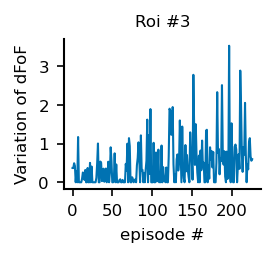

In [4]:
roi = 3
diffs = []
for i in range(len(episodes.dFoF[:,roi,:])):
    ini_val = episodes.dFoF[i,roi,1000]
    max_val = np.max(episodes.dFoF[i,roi,[1000,3000]])
    diff = max_val - ini_val
    diffs.append(diff)

plt.plot(diffs)
plt.xticks(np.arange(0,250,50)) 
plt.xlabel("episode #") 
plt.ylabel("Variation of dFoF")
plt.title(f"Roi #{roi}")

Difference across roi (mean of all episodes)

46


Text(0, 0.5, 'Variation of dFoF')

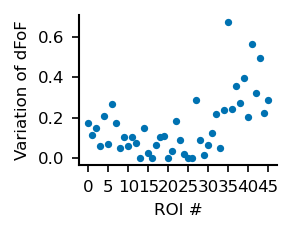

In [11]:
diffs = []
for i in range(len(episodes.dFoF[:,:,:].mean(axis=0))):
    ini_val = episodes.dFoF[:,i,1000].mean(axis=0)
    max_val = np.max(episodes.dFoF[:,i,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    diffs.append(diff)

print(len(diffs))
plt.scatter(np.arange(0, len(diffs),1), diffs)
plt.xticks(np.arange(0,len(diffs),5)) 
plt.xlabel("ROI #") 
plt.ylabel("Variation of dFoF")


## Differentiate active and resting state

In [6]:
def compute_high_movement_cond(episodes, running_speed_threshold):
    if running_speed_threshold is not None:
        HMcond = (episodes.running_speed > running_speed_threshold) 
    return HMcond

episodes active  :  4
episodes resting :  236
average for active episodes  : 0.29
average for resting episodes : 0.16


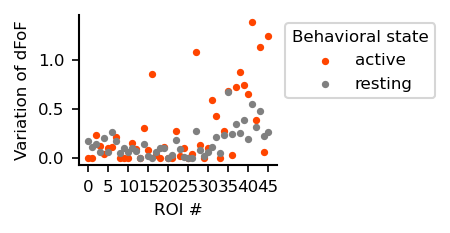

In [26]:
# HMcond: high movement condition
HMcond = compute_high_movement_cond(episodes, running_speed_threshold=0.1)
HMcond_ = HMcond[:, np.arange(1000, 3000)]  # Extracts values between 1000 and 2999
final_cond = []
for i in range(len(HMcond_)):
    if np.sum(HMcond[i])>1500:
        final_cond.append(True)
    else: 
        final_cond.append(False)


#active
episodes_act = episodes.dFoF[final_cond]
diffs_act = []
for i in range(len(episodes_act[:,:,:].mean(axis=0))):
    ini_val = episodes_act[:,i,1000].mean(axis=0)
    max_val = np.max(episodes_act[:,i,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    diffs_act.append(diff)

plt.scatter(np.arange(0, len(diffs_act),1), diffs_act, color='orangered', label = 'active')


#rest
final_cond = np.array(final_cond) 
episodes_rest = episodes.dFoF[~final_cond]

diffs_rest = []
n_roi = len(episodes_rest[:,:,:].mean(axis=0))

for roi in range(n_roi):
    ini_val = episodes_rest[:,roi,1000].mean(axis=0)
    max_val = np.max(episodes_rest[:,roi,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    diffs_rest.append(diff)

plt.scatter(np.arange(0, len(diffs_rest),1), diffs_rest, color='grey', label="resting")
#plt.set_xlabel("ROI #")
plt.xlabel("ROI #") 
plt.ylabel("Variation of dFoF")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title = "Behavioral state")
plt.xticks(np.arange(0,len(diffs_rest),5))  

print("episodes active  : ", len(episodes_act))
print("episodes resting : ", len(episodes_rest))
print(f"average for active episodes  : {np.mean(diffs_act):.2f}" )
print(f"average for resting episodes : {np.mean(diffs_rest):.2f}")

For each ROI, the variation of dFoF was plotted diving active and resting episodes (active were averaged together and resting were averaged together). Active episodes seem to be correlated to a bigger variation of dFoF.

## ALL files analysis

In [21]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs_test')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]


variations_act = []
variations_rest = []

for index in range(len(SESSIONS['files'])):
    filename = SESSIONS['files'][index]
    data = Data(filename,
                verbose=False)
    data.build_dFoF(verbose=False)
    
    episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name=data.protocols,
                       prestim_duration=0,
                       verbose=False)

    # HMcond: high movement condition
    HMcond = compute_high_movement_cond(episodes, running_speed_threshold=0.1)
    HMcond_ = HMcond[:, np.arange(1000, 3000)]  # Extracts values between 1000 and 2999
    final_cond = []
    for i in range(len(HMcond_)):
        if np.sum(HMcond[i])>1500:
            final_cond.append(True)
        else: 
            final_cond.append(False)
    
    
    #active
    episodes_act = episodes.dFoF[final_cond]
    diffs_act = []
    n_roi = len(episodes_act[:,:,:].mean(axis=0))
    for i in range(n_roi):
        ini_val = episodes_act[:,i,1000].mean(axis=0)
        max_val = np.max(episodes_act[:,i,[1000,3000]].mean(axis=0))
        diff = max_val - ini_val
        diffs_act.append(diff)
        
    variations_act.append(np.mean(diffs_act))    

    
    #rest
    final_cond = np.array(final_cond) 
    episodes_rest = episodes.dFoF[~final_cond]
    
    diffs_rest = []
    n_roi = len(episodes_rest[:,:,:].mean(axis=0))
    
    for roi in range(n_roi):
        ini_val = episodes_rest[:,roi,1000].mean(axis=0)
        max_val = np.max(episodes_rest[:,roi,[1000,3000]].mean(axis=0))
        diff = max_val - ini_val
        diffs_rest.append(diff)
    
    variations_rest.append(np.mean(diffs_rest))  


inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\All_NWBs_test" [...]
 -> found n=17 datafiles (in 10.9s) 


number of files : 17
active mean : 0.37, resting mean : 0.31
t_stats : 0.7331611614769024, p_value : 0.47


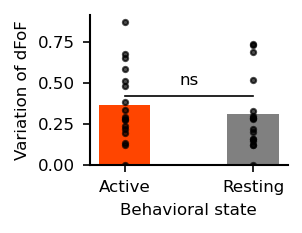

In [29]:
bar_width = 0.4
x = np.arange(2)  
means = [np.mean(variations_act), np.mean(variations_rest)]
plt.bar(x, means, width=bar_width, color=['orangered', 'grey'])
plt.scatter(np.full_like(variations_act, x[0]), variations_act, color='black', zorder=4, label="Active", alpha=0.7)
plt.scatter(np.full_like(variations_rest, x[1]), variations_rest, color='black', zorder=4, label="Resting", alpha=0.7)
plt.xticks(x, ['Active', 'Resting'])
plt.xlabel("Behavioral state")
plt.ylabel("Variation of dFoF")

print("number of files :", len(variations_act))
print(f"active mean : {means[0]:.2f}, resting mean : {means[1]:.2f}")

t_stats, p_val = stats_func.ttest_ind(variations_act, variations_rest)
print(f"t_stats : {t_stats}, p_value : {p_val:.2f}")

significance = 'ns'                  
if p_val==np.nan or p_val>0.05:
    significance = 'ns'  # Default is "not significant"
elif p_val < 0.001:
    significance = '***'
elif p_val < 0.01:
    significance = '**'
elif p_val < 0.05:
    significance = '*'

plt.plot([x[0], x[1]], [np.max([means[0], means[1]]) + 0.05] * 2, color='black', lw=0.8)  # Line above bars

# Annotate the significance above the line
plt.text(np.mean(x), np.max([means[0], means[1]]) + 0.1, f"{significance}", ha='center', va='bottom', fontsize=8)
plt.show()

For each file, active and resting values for the variation of dFoF. No difference for now